# Merge Original Data and Synthetic Data

In [63]:
import pandas as pd

email_batch_1 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Email Qwen Priority Dataset/email_batch_1_priority_qwen2.5.csv')
email_batch_2 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Email Qwen Priority Dataset/email_batch_2_priority_qwen2.5.csv')
#email_synthetic_data = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/FYP PART 2/Priority Modeling/cleaned_priority_synthetic_balanced_full_dataset.csv')
email_synthetic_data = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/FYP PART 2/Priority Modeling/cleaned_realistic_priority_email_dataset_full_format.csv')

original_data = pd.concat([email_batch_1, email_batch_2], ignore_index=True)
email_data = pd.concat([email_batch_1, email_batch_2, email_synthetic_data], ignore_index=True)

In [2]:
email_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148296 entries, 0 to 148295
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   From             148296 non-null  object
 1   To               146113 non-null  object
 2   Subject          148296 non-null  object
 3   Message          148296 non-null  object
 4   Day              148296 non-null  object
 5   Date & Time      148296 non-null  object
 6   url_count        148296 non-null  int64 
 7   Cleaned_Subject  147451 non-null  object
 8   Cleaned_Message  148183 non-null  object
 9   Combined_Text    148296 non-null  object
 10  Subject_LLM      148249 non-null  object
 11  Message_LLM      148272 non-null  object
 12  Email_Priority   148296 non-null  object
dtypes: int64(1), object(12)
memory usage: 14.7+ MB


In [3]:
# Display frequency counts for batch 1
print("Frequency of priority levels in batch 1:")
print(email_batch_1['Email_Priority'].value_counts())
# Display frequency counts for batch 2
print("\nFrequency of priority levels in batch 2:")
print(email_batch_2['Email_Priority'].value_counts())

# Display frequency counts for Synthetic Data
print("\nFrequency of priority levels Synthetic Data:")
print(email_synthetic_data['Email_Priority'].value_counts())

print("\nFrequency of combined priority levels:")
print(email_data['Email_Priority'].value_counts())

Frequency of priority levels in batch 1:
Email_Priority
Medium    19630
Low         324
High         46
Name: count, dtype: int64

Frequency of priority levels in batch 2:
Email_Priority
Medium    19802
Low         131
High         67
Name: count, dtype: int64

Frequency of priority levels Synthetic Data:
Email_Priority
High      49319
Low       48977
Medium    10000
Name: count, dtype: int64

Frequency of combined priority levels:
Email_Priority
Medium    49432
High      49432
Low       49432
Name: count, dtype: int64


In [4]:
email_data.columns

Index(['From', 'To', 'Subject', 'Message', 'Day', 'Date & Time', 'url_count',
       'Cleaned_Subject', 'Cleaned_Message', 'Combined_Text', 'Subject_LLM',
       'Message_LLM', 'Email_Priority'],
      dtype='object')

In [5]:
email_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148296 entries, 0 to 148295
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   From             148296 non-null  object
 1   To               146113 non-null  object
 2   Subject          148296 non-null  object
 3   Message          148296 non-null  object
 4   Day              148296 non-null  object
 5   Date & Time      148296 non-null  object
 6   url_count        148296 non-null  int64 
 7   Cleaned_Subject  147451 non-null  object
 8   Cleaned_Message  148183 non-null  object
 9   Combined_Text    148296 non-null  object
 10  Subject_LLM      148249 non-null  object
 11  Message_LLM      148272 non-null  object
 12  Email_Priority   148296 non-null  object
dtypes: int64(1), object(12)
memory usage: 14.7+ MB


In [6]:
email_data["Email_Priority"].value_counts()

Email_Priority
Medium    49432
High      49432
Low       49432
Name: count, dtype: int64

Extremely Imbalance: High 113, Low 455, Medium 39432

Word Cloud for ML

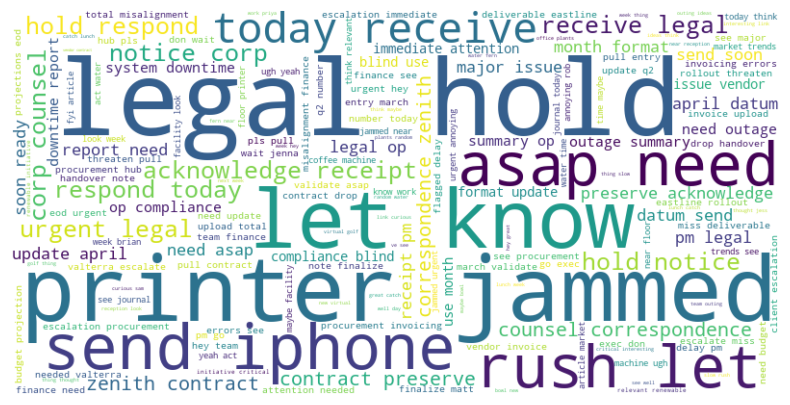

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = ' '.join(email_data['Combined_Text'].dropna())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.show()

Word Cloud for DL

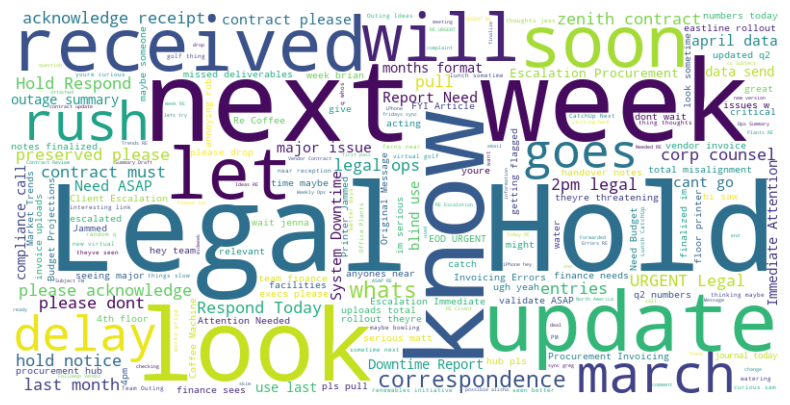

In [8]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

subject_text = ' '.join(email_data['Subject_LLM'].dropna())
message_text = ' '.join(email_data['Message_LLM'].dropna())

combined_text = subject_text + ' ' + message_text

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(combined_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.show()

ML Cleaned Text Top words Count - Unigram

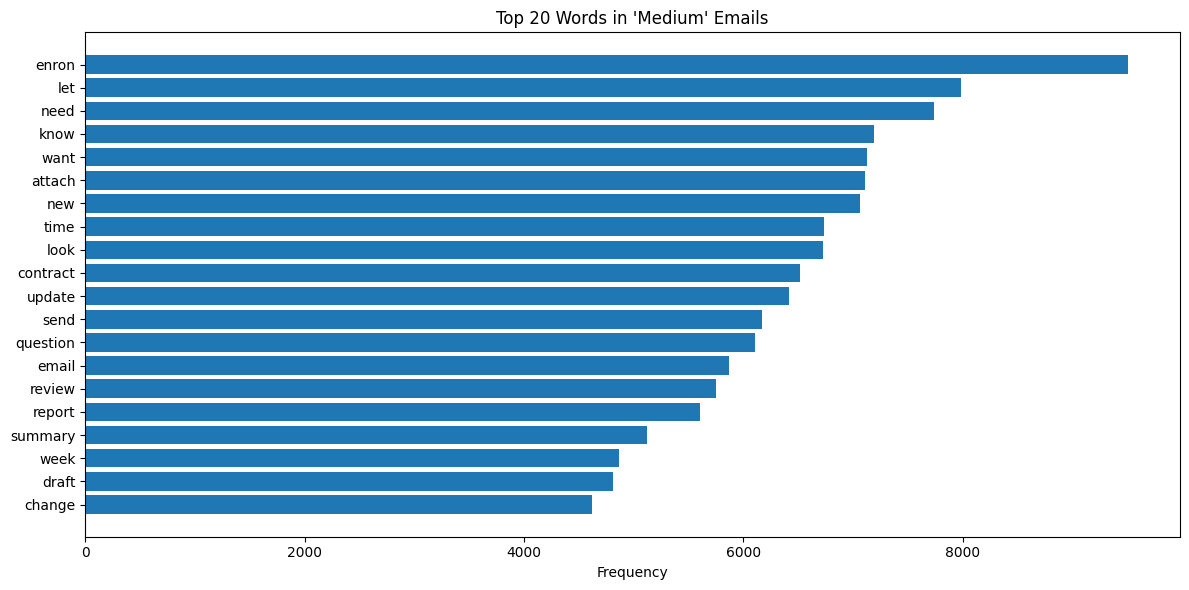

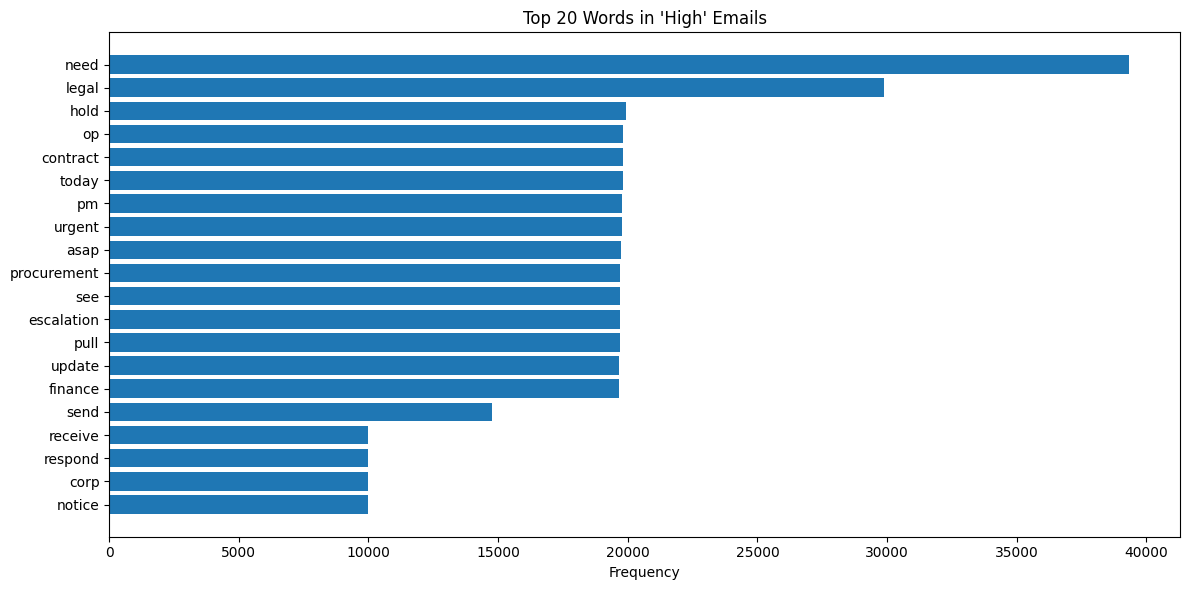

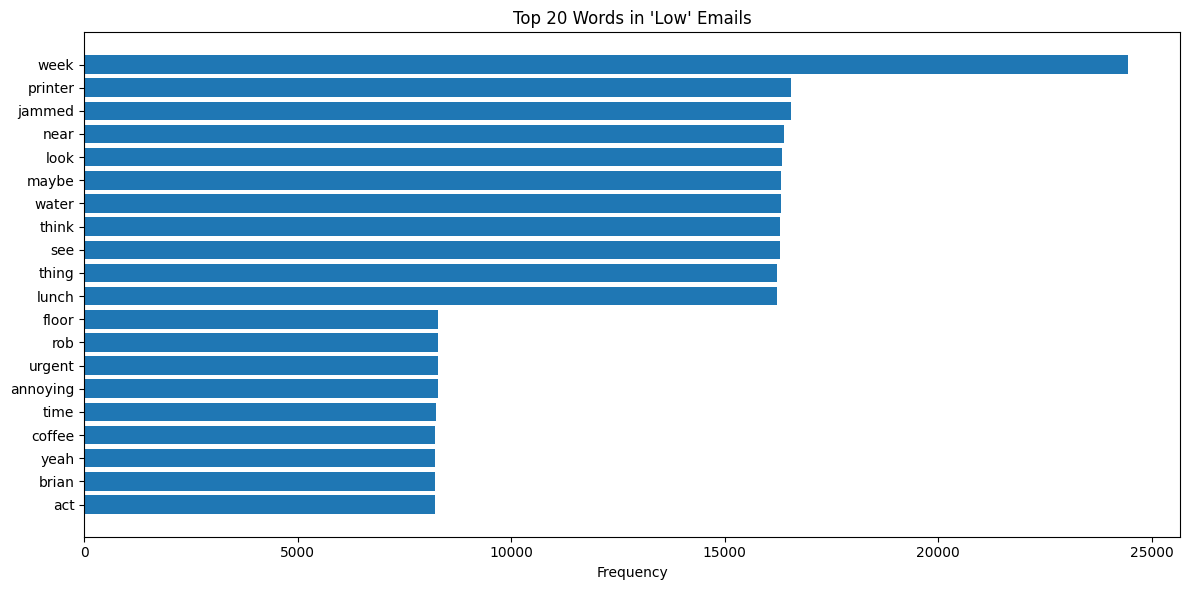

In [9]:
from collections import Counter
import matplotlib.pyplot as plt

categories = email_data['Email_Priority'].unique()

for category in categories:
    category_emails = email_data[email_data['Email_Priority'] == category]
    
    text = " ".join(str(msg) for msg in category_emails['Combined_Text'].dropna())
    words = text.split()
    
    word_freq = Counter(words)
    top_words = word_freq.most_common(20)
    
    if not top_words:
        continue

    labels, values = zip(*top_words)

    plt.figure(figsize=(12, 6))
    plt.barh(labels, values)
    plt.xlabel("Frequency")
    plt.title(f"Top 20 Words in '{category}' Emails")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

<Figure size 1200x600 with 0 Axes>

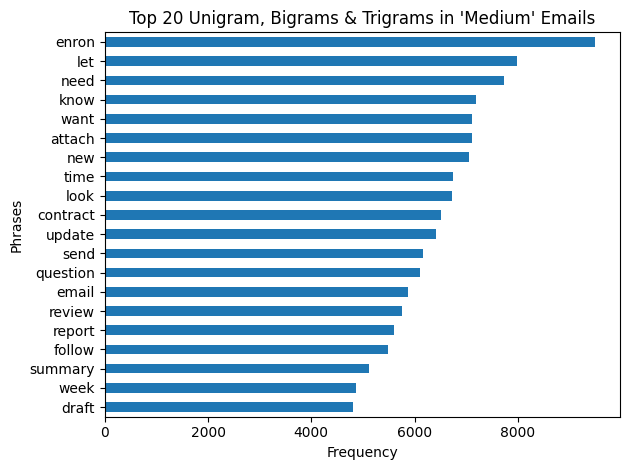

<Figure size 1200x600 with 0 Axes>

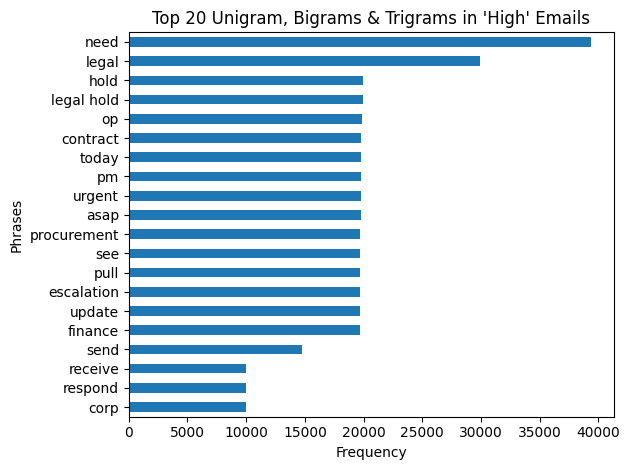

<Figure size 1200x600 with 0 Axes>

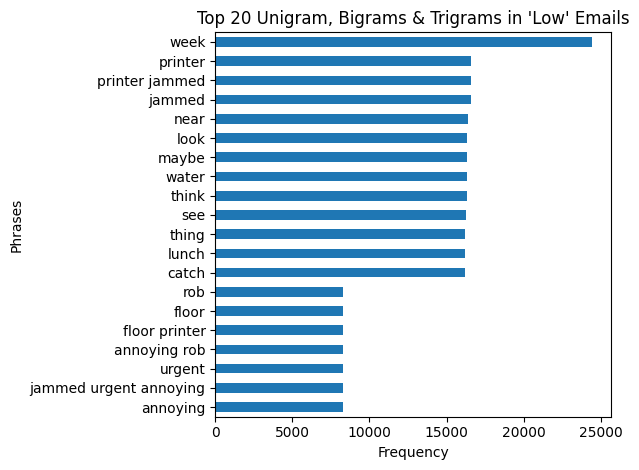

In [10]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import pandas as pd

categories = email_data['Email_Priority'].unique()

for category in categories:
    category_emails = email_data[email_data['Email_Priority'] == category]
    
    text_data = category_emails['Combined_Text'].dropna().astype(str).tolist()

    # Use CountVectorizer for bigrams and trigrams
    vectorizer = CountVectorizer(ngram_range=(1, 3))  # bigrams and trigrams
    X = vectorizer.fit_transform(text_data)

    # Fix: transpose the sum to get correct shape
    word_freq = pd.DataFrame(X.sum(axis=0).T, columns=["frequency"], index=vectorizer.get_feature_names_out())

    top_ngrams = word_freq.sort_values("frequency", ascending=False).head(20)

    if top_ngrams.empty:
        continue

    plt.figure(figsize=(12, 6))
    top_ngrams.sort_values("frequency").plot(kind="barh", legend=False)
    plt.title(f"Top 20 Unigram, Bigrams & Trigrams in '{category}' Emails")
    plt.xlabel("Frequency")
    plt.ylabel("Phrases")
    plt.tight_layout()
    plt.show()

🔺 High Priority - Frequent phrases: need, urgent, asap, today, legal hold, contract, escalation, finance, procurement, update, respond, corp - Implication: Clear use of time-sensitive and action-driven language, Legal or contractual terms are prominent → suggesting compliance-related urgency, Words like "need", "respond", "asap", and "urgent" consistently align with high-priority cues.

🟡 Medium Priority - Frequent phrases: enron, let, need, attach, look, review, update, email, draft, summary - Implication: More task-focused, with moderate urgency, Mentions of documentation (attach, draft, review) are common, Often refers to ongoing workflows without deadline pressure

🔻 Low Priority - Top phrases: printer, jammed, week, water, maybe, look, see, think, lunch, annoying - Implication: Conversational or trivial tone, Includes facilities issues or casual catch-ups, Lower frequency of action-demanding verbs (e.g., “reply,” “complete”)

Average Sentiment Analysis for each category

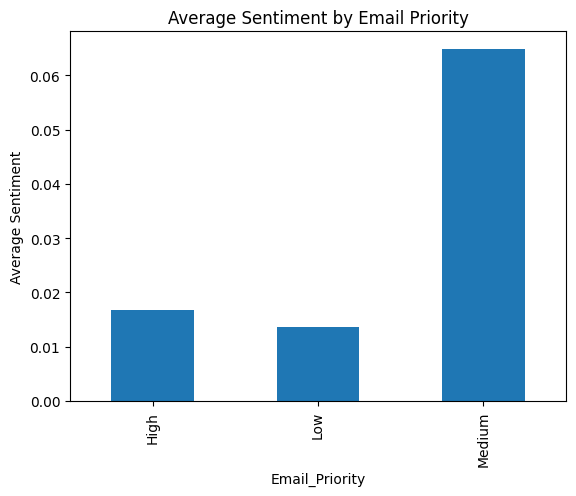

In [11]:
from textblob import TextBlob

# Function to calculate sentiment
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

# Apply sentiment analysis to the email content
email_data['sentiment'] = email_data['Combined_Text'].apply(get_sentiment)

# Group by Email_Priority and calculate average sentiment
sentiment_analysis = email_data.groupby('Email_Priority')['sentiment'].mean()

# Plotting the average sentiment
sentiment_analysis.plot(kind='bar', title='Average Sentiment by Email Priority')
plt.ylabel('Average Sentiment')
plt.show()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


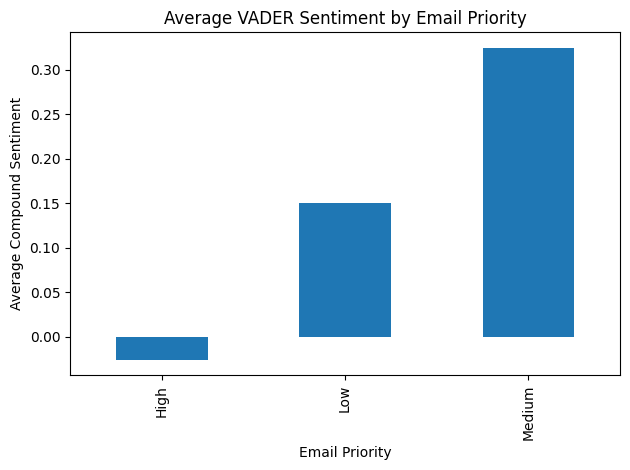

In [17]:
import nltk
nltk.download('vader_lexicon')

from nltk.sentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

# Initialize VADER
vader = SentimentIntensityAnalyzer()

# Define a function to extract the compound sentiment score
def get_vader_sentiment(text):
    if not isinstance(text, str) or text.strip() == "":
        return 0.0
    return vader.polarity_scores(text)['compound']

# Apply VADER to your data
email_data['vader_sentiment'] = email_data['Combined_Text'].apply(get_vader_sentiment)

# Group and visualize
sentiment_avg = email_data.groupby("Email_Priority")["vader_sentiment"].mean()
sentiment_avg.plot(kind='bar', title='Average VADER Sentiment by Email Priority')
plt.ylabel('Average Compound Sentiment')
plt.xlabel('Email Priority')
plt.tight_layout()
plt.show()

In [64]:
urgency_keywords = r'\b(' \
    r'asap|urgent|immediately|eod|cob|today|now|this morning|before (noon|lunch)|by (end of day|eod|cob|[0-9]{1,2}(am|pm)?|[a-z]+day)|' \
    r'priority|critical|time[-\s]?sensitive|action required|respond (now|immediately)|high priority|top priority|' \
    r'follow up|fast track|time constraint|on hold until|last chance|blocker|expedite|delayed|' \
    r'execs?|management attention|required urgently' \
r')\b'

email_data['urgency_flag'] = email_data['Combined_Text'].str.contains(urgency_keywords, case=False).astype(int)

C:\Users\User\AppData\Local\Temp\ipykernel_6260\2099238925.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  email_data['urgency_flag'] = email_data['Combined_Text'].str.contains(urgency_keywords, case=False).astype(int)


In [56]:
email_data['urgency_flag'].value_counts()

urgency_flag
0    85455
1    62841
Name: count, dtype: int64

In [65]:
risk_keywords = r'\b(' \
    r'compliance|non[-\s]?compliance|audit|breach|violation|investigation|penalty|risk|legal|' \
    r'flagged|security issue|security alert|escalation|required by law|subject to|' \
    r'consequences|failure to comply|enforcement|regulatory|incident report|policy breach|' \
    r'contractual|liability|risk exposure|internal control|control issue|mitigation|ops risk' \
r')\b'

email_data['risk_flag'] = email_data['Combined_Text'].str.contains(risk_keywords, case=False).astype(int)

C:\Users\User\AppData\Local\Temp\ipykernel_6260\3159554154.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  email_data['risk_flag'] = email_data['Combined_Text'].str.contains(risk_keywords, case=False).astype(int)


In [66]:
email_data['urgency_and_risk'] = (
    (email_data['urgency_flag'] == 1) & (email_data['risk_flag'] == 1)
).astype(int)

In [27]:
# Example binning the sentiment into 3 categories: Positive, Neutral, Negative
def categorize_sentiment(score):
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

email_data['sentiment_category'] = email_data['vader_sentiment'].apply(categorize_sentiment)

In [28]:
email_data['high_urgency_sentiment'] = (email_data['urgency_flag'] == 1) & (
    (email_data['vader_sentiment'] > 0.2) | (email_data['vader_sentiment'] < -0.2)
)

In [29]:
email_data = email_data.drop(columns=['sentiment', 'vader_sentiment', 'sentiment_category', 'high_urgency_sentiment'])

In [67]:
import re 

email_data['num_action_verbs'] = email_data['Combined_Text'].str.count(r'\b(send|review|approve|complete|submit|finalize|sign|escalate|follow up)\b')
email_data['num_uppercase_words_subject'] = email_data['Subject'].str.findall(r'\b[A-Z]{2,}\b').apply(len)
email_data['num_uppercase_words_message'] = email_data['Message'].str.findall(r'\b[A-Z]{2,}\b').apply(len)
email_data['num_uppercase_words_total'] = email_data['num_uppercase_words_subject'] + email_data['num_uppercase_words_message']
email_data['subject_len'] = email_data['Subject'].apply(lambda x: len(str(x).split()))
email_data['message_len'] = email_data['Message'].apply(lambda x: len(str(x).split()))

In [68]:
# ✅ Improved has_deadline
email_data['has_deadline'] = email_data['Combined_Text'].str.contains(
    r'\b('
    r'by|before|due|on|at|until|no later than|'
    r'eod|cob|end of day|end of week|'
    r'tomorrow|today|next week|next month|this week'
    r')\s+('
    r'(mon|tues|wednes|thurs|fri|sat|sun)(day)?|'
    r'\d{1,2}([:/.-]\d{1,2})?(am|pm)?|'
    r'\d{4}|\d{1,2}(th|st|nd|rd)?|'
    r'noon|midnight|morning|evening|afternoon'
    r')\b',
    flags=re.IGNORECASE
).astype(int)

# ✅ Improved threat_flag
email_data['threat_flag'] = email_data['Combined_Text'].str.contains(
    r'\b('
    r'virus|phishing|malware|breach|'
    r'data leak|data loss|unauthorized access|'
    r'compromised|security alert|ransomware|'
    r'cyber attack|credentials leak|account hacked|suspicious login'
    r')\b',
    flags=re.IGNORECASE
).astype(int)

C:\Users\User\AppData\Local\Temp\ipykernel_6260\2219133235.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  email_data['has_deadline'] = email_data['Combined_Text'].str.contains(
C:\Users\User\AppData\Local\Temp\ipykernel_6260\2219133235.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  email_data['threat_flag'] = email_data['Combined_Text'].str.contains(


In [69]:
formal_words = set(['please', 'kindly', 'appreciate', 'confirm', 'advise', 'request'])
def formality(text):
    words = str(text).lower().split()
    if not words: return 0
    return sum(w in formal_words for w in words) / len(words)

email_data['formality_score'] = email_data['Combined_Text'].apply(formality)

In [70]:
email_data['has_question'] = email_data['Message'].str.contains(r'\?', regex=True).astype(int)
email_data['is_threaded_email'] = email_data['Subject'].str.lower().str.startswith(('re:', 'fw:', 'fwd:')).astype(int)
email_data['num_sentences'] = email_data['Message'].str.count(r'\.')

In [71]:
email_data.columns

Index(['From', 'To', 'Subject', 'Message', 'Day', 'Date & Time', 'url_count',
       'Cleaned_Subject', 'Cleaned_Message', 'Combined_Text', 'Subject_LLM',
       'Message_LLM', 'Email_Priority', 'urgency_flag', 'risk_flag',
       'urgency_and_risk', 'num_action_verbs', 'num_uppercase_words_subject',
       'num_uppercase_words_message', 'num_uppercase_words_total',
       'subject_len', 'message_len', 'has_deadline', 'threat_flag',
       'formality_score', 'has_question', 'is_threaded_email',
       'num_sentences'],
      dtype='object')

C:\Users\User\AppData\Local\Temp\ipykernel_6260\79036674.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sentiment = email_data.resample('M')['sentiment'].mean()


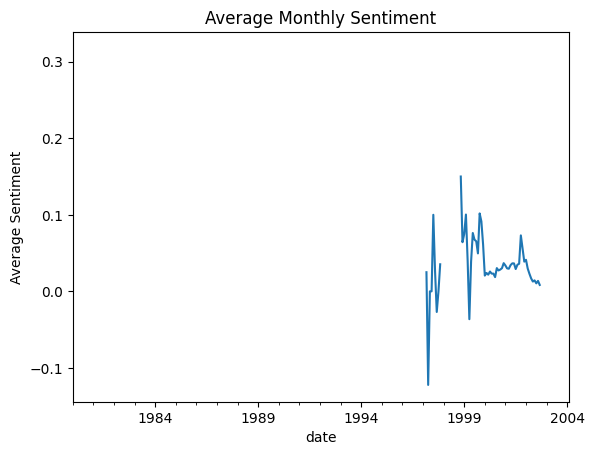

In [12]:
# Example: Analyzing sentiment over time
email_data['date'] = pd.to_datetime(email_data['Date & Time'])  # Replace with your date column
email_data.set_index('date', inplace=True)

# Resampling to get average sentiment by month
monthly_sentiment = email_data.resample('M')['sentiment'].mean()

# Plotting the trend
monthly_sentiment.plot(title='Average Monthly Sentiment')
plt.ylabel('Average Sentiment')
plt.show()

In [77]:
# Map Email_Priority to numeric values
priority_map = {'Low': 0, 'Medium': 1, 'High': 2}
email_data['Email_Priority'] = email_data['Email_Priority'].map(priority_map)

Low 0, Medium 1, High 2

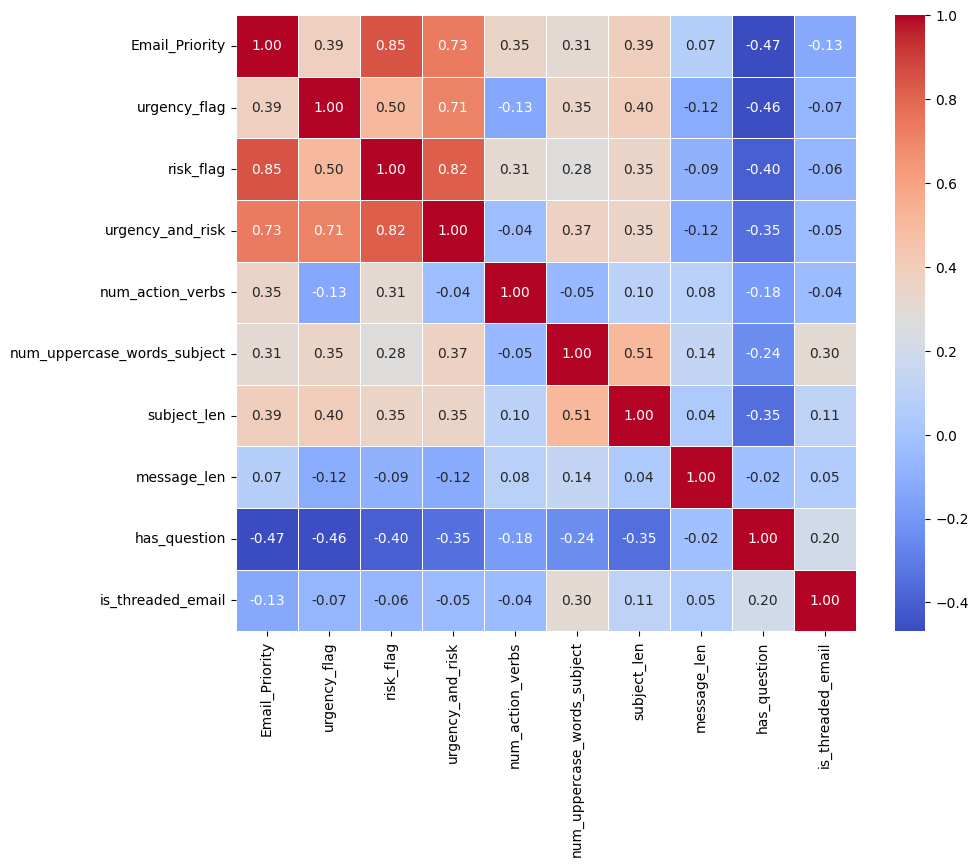

In [78]:
# Drop the columns you don't want to analyze
columns_to_exclude = ['From', 'To', 'Subject', 'Message', 'Day', 'Date & Time', 
       'Cleaned_Subject', 'Cleaned_Message', 'Combined_Text', 'Subject_LLM',
       'Message_LLM']
df_reduced = email_data.drop(columns=columns_to_exclude)

# Now calculate the correlation matrix on the remaining numerical columns
correlation_matrix = df_reduced.corr()

# Plot the heatmap for better visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.show()

✅ Most Predictive - urgency_flag, num_action_verbs, subject_len, num_uppercase_words_subject

⚠️ May be Redundant or Weak Alone - message_len vs. num_sentences — pick one and num_uppercase_words_total — remove if already using subject/message separately

🔍 Hidden Gems - has_question is negatively predictive — surprisingly useful for spotting non-urgent communication and formality_score shows low but real influence (especially on Medium-priority)

In [72]:
email_data = email_data.drop(columns=['num_uppercase_words_total', 'num_sentences', 'url_count', 'num_uppercase_words_message'])

In [73]:
email_data = email_data.drop(columns=['formality_score', 'has_deadline', 'threat_flag'])

In [79]:
email_data = email_data.drop(columns=['message_len', 'is_threaded_email'])

In [74]:
email_data.columns

Index(['From', 'To', 'Subject', 'Message', 'Day', 'Date & Time',
       'Cleaned_Subject', 'Cleaned_Message', 'Combined_Text', 'Subject_LLM',
       'Message_LLM', 'Email_Priority', 'urgency_flag', 'risk_flag',
       'urgency_and_risk', 'num_action_verbs', 'num_uppercase_words_subject',
       'subject_len', 'message_len', 'has_question', 'is_threaded_email'],
      dtype='object')

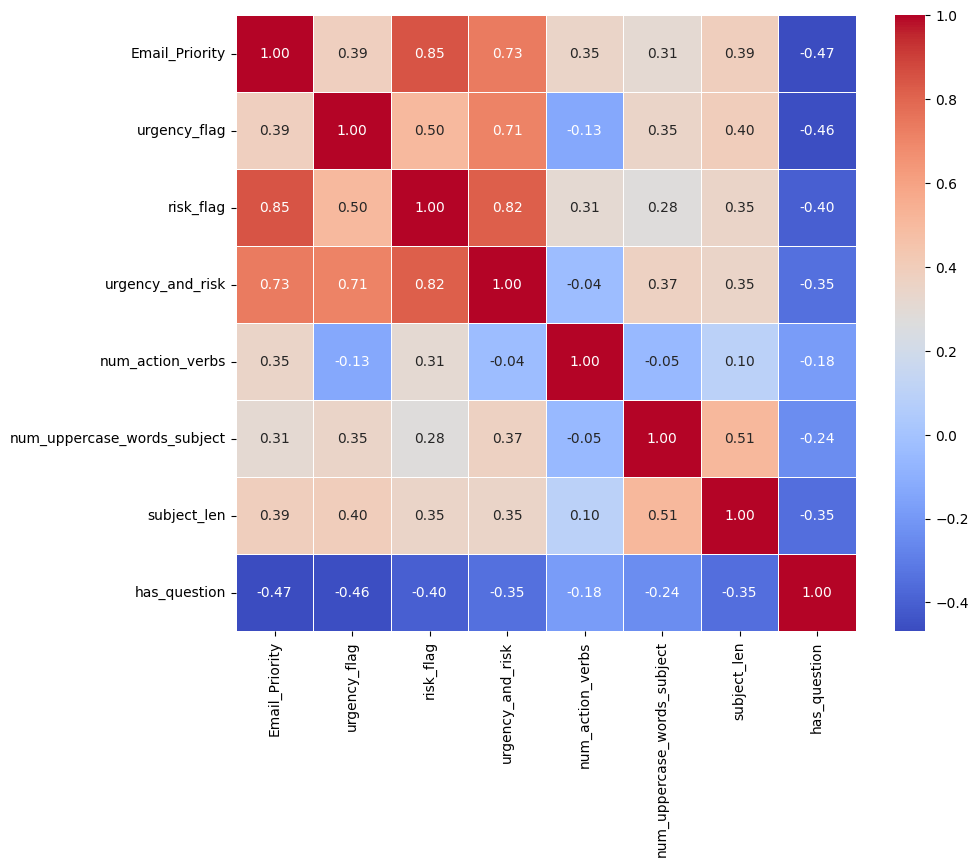

In [80]:
# Drop the columns you don't want to analyze
columns_to_exclude = ['From', 'To', 'Subject', 'Message', 'Day', 'Date & Time', 
       'Cleaned_Subject', 'Cleaned_Message', 'Combined_Text', 'Subject_LLM',
       'Message_LLM']
df_reduced = email_data.drop(columns=columns_to_exclude)

# Now calculate the correlation matrix on the remaining numerical columns
correlation_matrix = df_reduced.corr()

# Plot the heatmap for better visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.show()

Feature	What It Detects	Why It’s Useful
- urgency_flag	Urgent terms like “asap”, “urgent”	Strong signal for High priority
- num_action_verbs	Count of directive words (e.g., send, review)	Indicates task-based or directive communication
- subject_len	Number of words in subject line	Longer = more detailed → often Medium priority
- num_uppercase_words_subject	CAPS in subject (e.g., “URGENT”)	Emphasis for High priority messages
- has_question	Presence of question mark	Suggests Medium or Low priority (not directives)
- formality_score	Ratio of formal words	Medium priority emails are often more polite
- has_deadline	Phrases like “by Friday”, “before 3pm”	Indicates time-sensitive tasks — often High
- threat_flag	Security alert terms (e.g., virus, breach)	Rare but highly relevant for High priority alerts
- is_threaded_email	Starts with RE:, FWD:	Ongoing convos — often Medium or Low
- message_len Sentence count in message	More structure/detail → often Medium priority

In [83]:
# Save the DataFrame to a CSV file
email_data.to_csv('cleaned_priority_email_dataset.csv', index=False)

In [ ]:
email_data

In [82]:
import pandas as pd

# --- Step 1: Define the subset creation function ---
def create_priority_subset(email_data, priority_col='Email_Priority', samples_per_class=100, random_state=42):
    """
    Create a balanced subset of the email dataset with equal samples from each priority class.

    Parameters:
        email_data (DataFrame): Your dataset containing the encoded priority column.
        priority_col (str): The column name with priority values (0=Low, 1=Medium, 2=High).
        samples_per_class (int): How many emails to include per class.
        random_state (int): Seed for reproducibility.

    Returns:
        DataFrame: Balanced subset.
    """
    subset_list = [
        email_data[email_data[priority_col] == priority].sample(n=samples_per_class, random_state=random_state)
        for priority in sorted(email_data[priority_col].unique())
    ]
    
    return pd.concat(subset_list).reset_index(drop=True)

# --- Step 2: Create the subset from your dataset ---
subset_email_data = create_priority_subset(email_data, priority_col='Email_Priority', samples_per_class=100)

# --- Step 3: Export to CSV ---
subset_email_data.to_csv("priority_subset_300.csv", index=False)

# --- Optional: Confirm success ---
print("✅ Subset saved as priority_subset_300.csv")
print(subset_email_data['Email_Priority'].value_counts())

✅ Subset saved as priority_subset_300.csv
Email_Priority
0    100
1    100
2    100
Name: count, dtype: int64


# Model Building Test - Original Data only

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split

# Combine text columns if needed
text_data = email_data['Combined_Text']  # or use other text columns like 'Subject', 'Message'

# Vectorize the text data using TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # Adjust max_features as needed
X_tfidf = tfidf_vectorizer.fit_transform(text_data)

# Convert to DataFrame for compatibility with SelectKBest
X_tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Separate target variable
y = email_data['Email_Priority']

# Apply SelectKBest with chi2
chi2_selector = SelectKBest(chi2, k=50)  # Select top 50 features
X_selected = chi2_selector.fit_transform(X_tfidf_df, y)

# Get selected feature names
selected_features = X_tfidf_df.columns[chi2_selector.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['act', 'annoying', 'asap', 'blind', 'bowl', 'brian', 'catch', 'coffee',
       'deliverable', 'downtime', 'eastline', 'escalate', 'escalation',
       'facility', 'fern', 'finance', 'golf', 'handover', 'hold', 'ideas',
       'jammed', 'jess', 'legal', 'look', 'lunch', 'machine', 'maybe', 'near',
       'need', 'needed', 'op', 'outing', 'plants', 'pm', 'printer',
       'procurement', 'pull', 'random', 'reception', 'rollout', 'thing',
       'think', 'threaten', 'ugh', 'valterra', 've', 'virtual', 'water',
       'week', 'yeah'],
      dtype='object')


In [23]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

In [24]:
from sklearn.linear_model import LogisticRegression

# Initialize the model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [25]:
from sklearn.metrics import classification_report, accuracy_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9926500337154417
Classification Report:
               precision    recall  f1-score   support

        High       1.00      1.00      1.00     10070
         Low       0.99      0.99      0.99      9805
      Medium       0.99      0.99      0.99      9785

    accuracy                           0.99     29660
   macro avg       0.99      0.99      0.99     29660
weighted avg       0.99      0.99      0.99     29660



In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {'C': [0.1, 1, 10, 100]}

# Initialize Grid Search
grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5)

# Fit Grid Search
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'C': 100}


In [ ]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_selected, y)

# Check the new class distribution
print("Resampled class distribution:")
print(y_resampled.value_counts())

Resampled class distribution:
Email_Priority
Medium    39432
High      39432
Low       39432
Name: count, dtype: int64


In [ ]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {'C': [0.1, 1, 10, 100]}

# Initialize Grid Search
grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5)

# Fit Grid Search
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'C': 100}


In [ ]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation
scores = cross_val_score(model, X_selected, y, cv=5)
print("Cross-validation scores:", scores)
print("Mean cross-validation score:", scores.mean())

Cross-validation scores: [0.81875  0.82125  0.783875 0.836    0.748375]
Mean cross-validation score: 0.8016500000000001


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7875
Classification Report:
               precision    recall  f1-score   support

        High       0.03      0.86      0.05        21
         Low       0.05      0.63      0.09        84
      Medium       1.00      0.79      0.88      7895

    accuracy                           0.79      8000
   macro avg       0.36      0.76      0.34      8000
weighted avg       0.98      0.79      0.87      8000



In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distribution
param_dist = {'C': [0.01, 0.1, 1, 10, 100, 1000]}

# Initialize Randomized Search
random_search = RandomizedSearchCV(LogisticRegression(max_iter=1000), param_dist, n_iter=10, cv=5, random_state=42)

# Fit Randomized Search
random_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", random_search.best_params_)

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Parameters: {'C': 100}


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train a Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate the Random Forest model
y_rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_rf_pred))
print("Random Forest Classification Report:\n", classification_report(y_test, y_rf_pred))

Random Forest Accuracy: 0.98325
Random Forest Classification Report:
               precision    recall  f1-score   support

        High       0.14      0.10      0.11        21
         Low       0.31      0.19      0.24        84
      Medium       0.99      0.99      0.99      7895

    accuracy                           0.98      8000
   macro avg       0.48      0.43      0.45      8000
weighted avg       0.98      0.98      0.98      8000



In [ ]:
from sklearn.ensemble import VotingClassifier

# Create an ensemble of models
ensemble_model = VotingClassifier(estimators=[
    ('lr', model),
    ('rf', rf_model)
], voting='soft')

# Train the ensemble model
ensemble_model.fit(X_train, y_train)

# Evaluate the ensemble model
y_ensemble_pred = ensemble_model.predict(X_test)
print("Ensemble Accuracy:", accuracy_score(y_test, y_ensemble_pred))
print("Ensemble Classification Report:\n", classification_report(y_test, y_ensemble_pred))

Ensemble Accuracy: 0.9745
Ensemble Classification Report:
               precision    recall  f1-score   support

        High       0.15      0.43      0.22        21
         Low       0.26      0.36      0.30        84
      Medium       0.99      0.98      0.99      7895

    accuracy                           0.97      8000
   macro avg       0.47      0.59      0.50      8000
weighted avg       0.98      0.97      0.98      8000



In [ ]:
from imblearn.combine import SMOTETomek

# Apply SMOTETomek
smote_tomek = SMOTETomek(random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X_selected, y)

# Check the new class distribution
print("Resampled class distribution:")
print(y_resampled.value_counts())

Resampled class distribution:
Email_Priority
High      38539
Low       38207
Medium    37976
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train a Random Forest model with class weights
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Evaluate the Random Forest model
y_rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_rf_pred))
print("Random Forest Classification Report:\n", classification_report(y_test, y_rf_pred))

Random Forest Accuracy: 0.982375
Random Forest Classification Report:
               precision    recall  f1-score   support

        High       0.23      0.33      0.27        21
         Low       0.30      0.17      0.21        84
      Medium       0.99      0.99      0.99      7895

    accuracy                           0.98      8000
   macro avg       0.50      0.50      0.49      8000
weighted avg       0.98      0.98      0.98      8000



In [ ]:
from skopt import BayesSearchCV

# Define the parameter search space
param_space = {
    'n_estimators': (10, 1000),
    'max_depth': (1, 50),
    'min_samples_split': (2, 20),
    'min_samples_leaf': (1, 20)
}

# Initialize Bayesian Search
bayes_search = BayesSearchCV(RandomForestClassifier(random_state=42), param_space, n_iter=32, cv=5, random_state=42)

# Fit Bayesian Search
bayes_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", bayes_search.best_params_)

In [ ]:
from xgboost import XGBClassifier

# Initialize and train an XGBoost model
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

# Evaluate the XGBoost model
y_xgb_pred = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_xgb_pred))
print("XGBoost Classification Report:\n", classification_report(y_test, y_xgb_pred))

In [ ]:
from sklearn.ensemble import StackingClassifier

# Create a stacking ensemble of models
stacking_model = StackingClassifier(estimators=[
    ('lr', model),
    ('rf', rf_model),
    ('xgb', xgb_model)
], final_estimator=LogisticRegression())

# Train the stacking model
stacking_model.fit(X_train, y_train)

# Evaluate the stacking model
y_stacking_pred = stacking_model.predict(X_test)
print("Stacking Accuracy:", accuracy_score(y_test, y_stacking_pred))
print("Stacking Classification Report:\n", classification_report(y_test, y_stacking_pred))

# Model Building Test - Original Data and Synthetic Data

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split

# Combine text columns if needed
text_data = email_data['Combined_Text']  # or use other text columns like 'Subject', 'Message'

# Vectorize the text data using TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # Adjust max_features as needed
X_tfidf = tfidf_vectorizer.fit_transform(text_data)

# Convert to DataFrame for compatibility with SelectKBest
X_tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Separate target variable
y = email_data['Email_Priority']

# Apply SelectKBest with chi2
chi2_selector = SelectKBest(chi2, k=50)  # Select top 50 features
X_selected = chi2_selector.fit_transform(X_tfidf_df, y)

# Get selected feature names
selected_features = X_tfidf_df.columns[chi2_selector.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['approval', 'board', 'budget', 'celebrate', 'cheer', 'client',
       'complete', 'compliance', 'congratulation', 'congratulations',
       'contract', 'cooperation', 'critical', 'delay', 'escalate', 'filing',
       'final', 'finalize', 'friday', 'hire', 'huge', 'immediately', 'impact',
       'issue', 'legal', 'lunch', 'new', 'newsletter', 'office', 'plan',
       'plans', 'pm', 'presentation', 'promotion', 'proud', 'regulatory',
       'report', 'response', 'review', 'submission', 'submit', 'team', 'think',
       'tidy', 'today', 'tomorrow', 'truly', 'version', 'warm', 'work'],
      dtype='object')


In [3]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

In [4]:
from sklearn.linear_model import LogisticRegression

# Initialize the model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [5]:
from sklearn.metrics import classification_report, accuracy_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9951776649746192
Classification Report:
               precision    recall  f1-score   support

        High       1.00      1.00      1.00      7898
         Low       1.00      0.99      0.99      7785
      Medium       0.99      1.00      0.99      7957

    accuracy                           1.00     23640
   macro avg       1.00      1.00      1.00     23640
weighted avg       1.00      1.00      1.00     23640



In [6]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train a Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate the Random Forest model
y_rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_rf_pred))
print("Random Forest Classification Report:\n", classification_report(y_test, y_rf_pred))

Random Forest Accuracy: 0.994331641285956
Random Forest Classification Report:
               precision    recall  f1-score   support

        High       1.00      1.00      1.00      7898
         Low       1.00      0.99      0.99      7785
      Medium       0.99      0.99      0.99      7957

    accuracy                           0.99     23640
   macro avg       0.99      0.99      0.99     23640
weighted avg       0.99      0.99      0.99     23640



In [9]:
from sklearn.preprocessing import LabelEncoder

# Encode labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Train the model
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train_encoded)

# Predict and evaluate
y_xgb_pred = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test_encoded, y_xgb_pred))
print("XGBoost Classification Report:\n", classification_report(y_test_encoded, y_xgb_pred, target_names=le.classes_))

XGBoost Accuracy: 0.9957275803722504
XGBoost Classification Report:
               precision    recall  f1-score   support

        High       1.00      1.00      1.00      7898
         Low       1.00      0.99      1.00      7785
      Medium       0.99      1.00      0.99      7957

    accuracy                           1.00     23640
   macro avg       1.00      1.00      1.00     23640
weighted avg       1.00      1.00      1.00     23640



In [10]:
from sklearn.ensemble import StackingClassifier

# Create a stacking ensemble of models
stacking_model = StackingClassifier(estimators=[
    ('lr', model),
    ('rf', rf_model),
    ('xgb', xgb_model)
], final_estimator=LogisticRegression())

# Train the stacking model
stacking_model.fit(X_train, y_train)

# Evaluate the stacking model
y_stacking_pred = stacking_model.predict(X_test)
print("Stacking Accuracy:", accuracy_score(y_test, y_stacking_pred))
print("Stacking Classification Report:\n", classification_report(y_test, y_stacking_pred))

Stacking Accuracy: 0.9957275803722504
Stacking Classification Report:
               precision    recall  f1-score   support

        High       1.00      1.00      1.00      7898
         Low       1.00      0.99      1.00      7785
      Medium       0.99      1.00      0.99      7957

    accuracy                           1.00     23640
   macro avg       1.00      1.00      1.00     23640
weighted avg       1.00      1.00      1.00     23640

